In [15]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import least_squares

from matching import build_roma_matcher, match_two_images_roma
import viz
import raft_stereo

In [13]:
K_rgb_L = np.array([[889.8174, 0, 375.1605], [0, 891.2550, 277.3332], [0, 0, 1]])
D_rgb_L = np.array([-0.20879, 0.14455, -0.00018, 0.00031])
K_rgb_R = np.array([[889.4472, 0, 365.3022], [0, 890.6761, 285.7608], [0, 0, 1]])
D_rgb_R = np.array([-0.20744, 0.14176, 0.00113, -0.00010])

q_rgb = np.array([0.01309, -0.01322, -0.00458, 0.99982])
t_rgb = np.array([0.32019, 0.00262, -0.00701])

# --- IR (Verified) ---
K_ir_L = np.array([[514.1837, 0, 327.5567], [0, 514.0445, 247.3693], [0, 0, 1]])
D_ir_L = np.array([-0.44319, 0.19562, 0.00103, -0.00171])
K_ir_R = np.array([[502.6188, 0, 299.1063], [0, 501.1625, 237.6147], [0, 0, 1]])
D_ir_R = np.array([-0.43438, 0.18212, 0.00317, 0.00299])

# IR Extrinsics (Right-in-Left)
# Derived from your Turn 11 IR matrix
# t_ir_1_0 was [0.31806963, 0.00035073, -0.00625176]
# q_ir_1_0 was [0.00467553, 0.00609199, -0.00175593, 0.99996897]
q_ir = np.array([0.00467553, 0.00609199, -0.00175593, 0.99996897])
t_ir = np.array([0.31806963, 0.00035073, -0.00625176])

path_rgb_L = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam1_image_raw/1.png"
path_rgb_R = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_camera_array_cam0_image_raw/1.png"
path_ir_L  = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_boson_camera_array_cam_0_image_raw/1.png"
path_ir_R  = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56/frluas3_boson_camera_array_cam_1_image_raw/1.png"

In [3]:

matcher_api = build_roma_matcher()

*****************cuda, False**************************


/home/nail/miniconda3/envs/gtsam-env/lib/python3.10/site-packages/pytorch_lightning/profiler/__init__.py:36: LightningDeprecationWarning: `pytorch_lightning.profiler.PassThroughProfiler` is deprecated in v1.9.0 and will be removed in v2.0.0. Use the equivalent `pytorch_lightning.profilers.PassThroughProfiler` class instead.
  rank_zero_deprecation(
2025-12-08 11:24:42.462 | INFO     | MatchAnything.src.lightning.lightning_loftr:__init__:76 - Load model from:<All keys matched successfully>
[2025/12/08 11:24:42 hloc INFO] Loading matchanything_roma model done


[2025/12/08 11:24:44 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:24:44 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1678 (limit=3000)
Found 1678 matches.


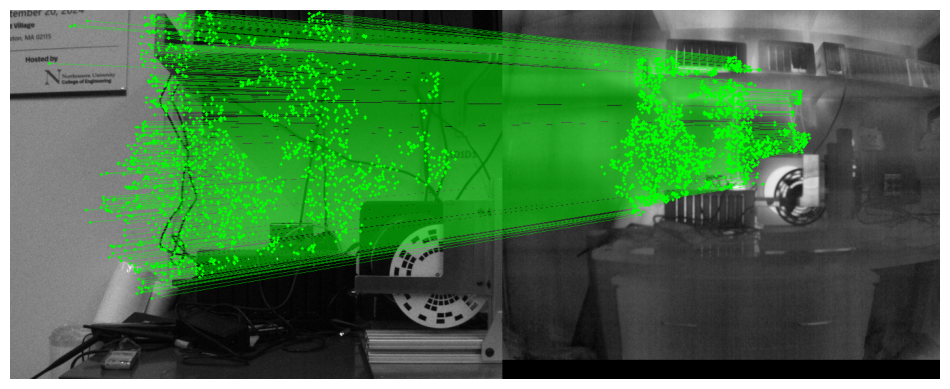

array([[[137, 137, 137],
        [141, 141, 141],
        [138, 138, 138],
        ...,
        [ 74,  74,  74],
        [ 72,  72,  72],
        [ 74,  74,  74]],

       [[136, 136, 136],
        [119, 119, 119],
        [127, 127, 127],
        ...,
        [ 80,  80,  80],
        [ 85,  85,  85],
        [ 88,  88,  88]],

       [[ 96,  96,  96],
        [ 92,  92,  92],
        [125, 125, 125],
        ...,
        [ 88,  88,  88],
        [ 98,  98,  98],
        [ 90,  90,  90]],

       ...,

       [[116, 116, 116],
        [122, 122, 122],
        [122, 122, 122],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[122, 122, 122],
        [118, 118, 118],
        [121, 121, 121],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[118, 118, 118],
        [112, 112, 112],
        [111, 111, 111],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

In [4]:
mkpts_rgb, mkpts_ir, mconf, rgb_gray, ir_gray = match_two_images_roma(
    matcher_api, path_rgb_L, path_ir_L, max_inliers=3000
)
print(f"Found {len(mkpts_rgb)} matches.")

viz.visualize_matches(rgb_gray, ir_gray, mkpts_rgb, mkpts_ir)


F-Matrix Inliers: 759 matches.
Visualizing epipolar lines...


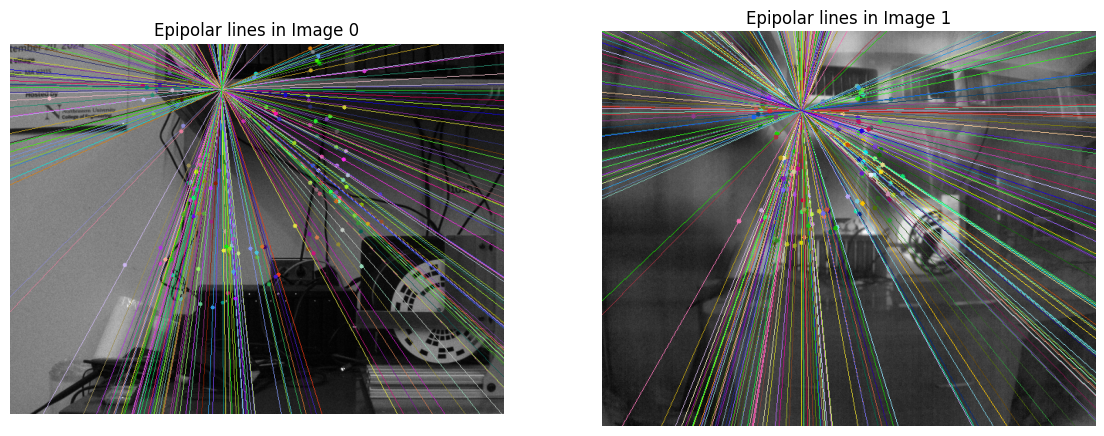

(array([[[137, 137, 137],
         [141, 141, 141],
         [138, 138, 138],
         ...,
         [ 23,  23,  23],
         [ 23,  23,  23],
         [ 24,  24,  24]],
 
        [[136, 136, 136],
         [119, 119, 119],
         [127, 127, 127],
         ...,
         [ 21,  21,  21],
         [ 16,  16,  16],
         [ 25,  25,  25]],
 
        [[ 96,  96,  96],
         [ 92,  92,  92],
         [125, 125, 125],
         ...,
         [ 19,  19,  19],
         [ 22,  22,  22],
         [ 19,  19,  19]],
 
        ...,
 
        [[116, 116, 116],
         [122, 122, 122],
         [122, 122, 122],
         ...,
         [ 73,  73,  73],
         [ 65,  65,  65],
         [ 67,  67,  67]],
 
        [[122, 122, 122],
         [118, 118, 118],
         [121, 121, 121],
         ...,
         [ 80,  80,  80],
         [ 80,  80,  80],
         [ 77,  77,  77]],
 
        [[118, 118, 118],
         [112, 112, 112],
         [111, 111, 111],
         ...,
         [ 93,  93,  93],
  

In [5]:
F, mask = cv2.findFundamentalMat(mkpts_rgb, mkpts_ir, cv2.FM_RANSAC, 0.5, 0.999)
# Filter points to just the inliers of the Fundamental Matrix
mask = mask.ravel().astype(bool)
mkpts_rgb_in = mkpts_rgb[mask]
mkpts_ir_in = mkpts_ir[mask]
print(f"F-Matrix Inliers: {len(mkpts_rgb_in)} matches.")
# 6. Draw Epipolar Lines
print("Visualizing epipolar lines...")
# shows the epipolar lines for the inlier points
viz.show_epipolar_lines(rgb_gray, ir_gray, mkpts_rgb_in, mkpts_ir_in, F, sample_step=5)


Calculated Baseline: 0.3203 m
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 3.600 pixels


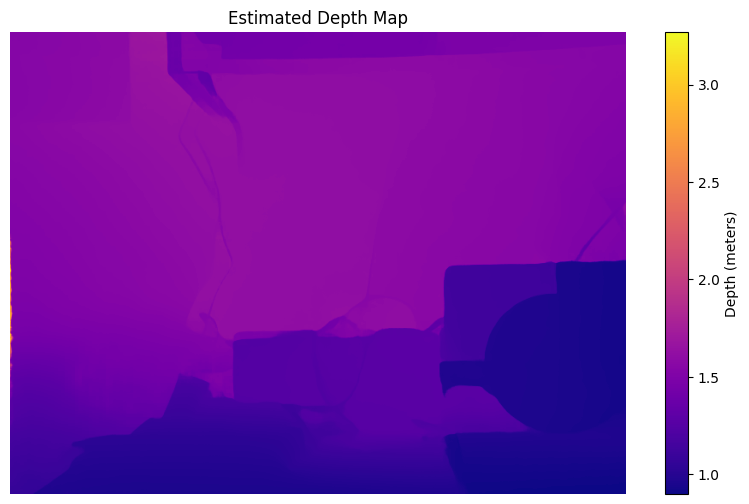

[Point Cloud] Displaying 38863 points (Original: 388800)


In [6]:

model_weights  = '/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/RAFT-Stereo/models/raftstereo-middlebury.pth'

model = raft_stereo.load_raft_model(model_weights)

img_size = (720, 540) # (W, H)
preprocessor = raft_stereo.StereoPreprocessor(
    K_rgb_L, D_ir_L, 
    K_rgb_R, D_rgb_R, 
    q_1_0, t_1_0, 
    img_size
)
print(f"Calculated Baseline: {preprocessor.extrinsics['baseline']:.4f} m")

raw_left = cv2.imread(path_rgb_L)
raw_right = cv2.imread(path_rgb_R)

preprocessor.auto_align(raw_left, raw_right)

rect_left, rect_right = preprocessor.rectify_images(raw_left, raw_right)

depth_map = raft_stereo.estimate_stereo_depth(
    rect_left, 
    rect_right, 
    model, 
    preprocessor.intrinsics, 
    preprocessor.extrinsics
)
depth_map = np.abs(depth_map) # Ensure positive

viz.plot_depth_map(depth_map)   
# viz.plot_point_cloud(depth_map, preprocessor.intrinsics, preprocessor.extrinsics)

pts3d = viz.backproject_depth(depth_map, preprocessor.intrinsics)
viz.plot_point_cloud(pts3d, rect_left, min_z=0.5, max_z=2.0, subsample=10)

Re-matching on Rectified Image...


[2025/12/08 11:24:57 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:24:57 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1433 (limit=3000)
Found 1433 matches on rectified image.
Points used for PnP: 1433
Solving PnP...

=== PnP SUCCESS ===
Translation Vector: [-0.01899093 -0.03765186  0.0298988 ]
Distance:           5.17 cm
Rotation Matrix:
[[ 0.99869064 -0.00850232 -0.05044519]
 [ 0.00708047  0.99957445 -0.02829822]
 [ 0.05066432  0.02790399  0.99832585]]
Visualizing 1053 inliers.
Mean Reprojection Error: 0.8548 pixels


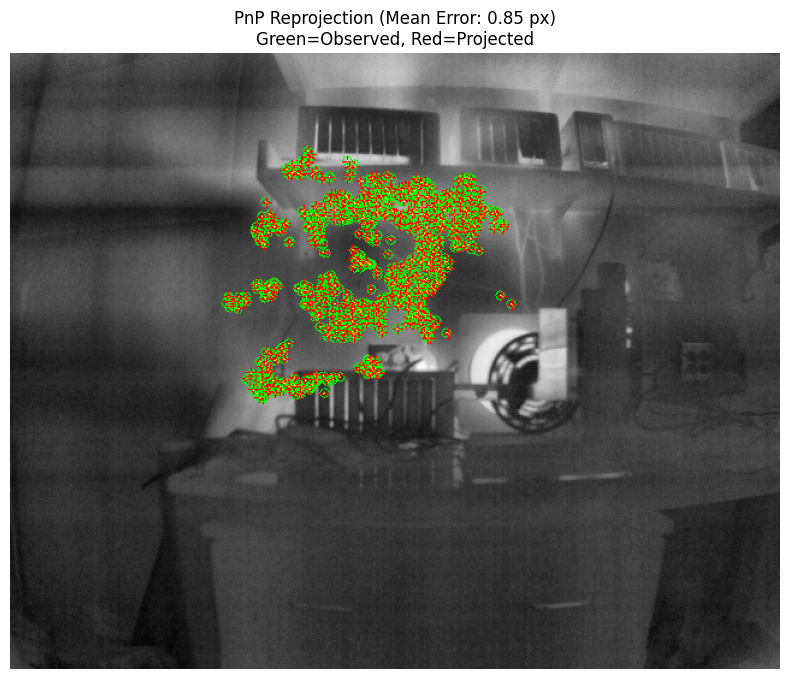

Reprojection Error: 0.85 px


In [ ]:
import cv2
import numpy as np


print("Re-matching on Rectified Image...")


# Run ROMA: Rectified RGB (Left) <-> Raw IR (Left)
mkpts_rgb, mkpts_ir, mconf, rgb_gray, ir_gray = match_two_images_roma(
    matcher_api, rect_left, path_ir_L, max_inliers=3000
)
print(f"Found {len(mkpts_rgb)} matches on rectified image.")

# viz.visualize_matches(rgb_gray, ir_gray, mkpts_rgb, mkpts_ir)

# Use the depth map (which is already aligned to rect_left)
u = np.round(mkpts_rgb[:, 0]).astype(int)
v = np.round(mkpts_rgb[:, 1]).astype(int)
H, W = depth_map.shape

# Bounds Check
valid_uv = (u >= 0) & (u < W) & (v >= 0) & (v < H)
u, v = u[valid_uv], v[valid_uv]
mkpts_rgb = mkpts_rgb[valid_uv]
mkpts_ir = mkpts_ir[valid_uv]

# Depth Check (Filter 0.5m - 10m)
z_vals = depth_map[v, u]
valid_z = (z_vals > 0.5) & (z_vals < 10.0)

z_final = z_vals[valid_z]
mkpts_ir_final = mkpts_ir[valid_z]
mkpts_rgb_final = mkpts_rgb[valid_z]

print(f"Points used for PnP: {len(z_final)}")

# Back-Project to 3D (Rectified Frame)
fx = preprocessor.intrinsics['fx']
fy = preprocessor.intrinsics['fy']
cx = preprocessor.intrinsics['cx1']
cy = preprocessor.intrinsics['cy']

x_3d = (mkpts_rgb_final[:, 0] - cx) * z_final / fx
y_3d = (mkpts_rgb_final[:, 1] - cy) * z_final / fy
z_3d = z_final

object_points = np.stack([x_3d, y_3d, z_3d], axis=1)

print("Solving PnP...")

success, rvec, tvec, inliers = cv2.solvePnPRansac(
    object_points,
    mkpts_ir_final,
    K_ir_L,
    D_ir_L,
    iterationsCount=5000,
    reprojectionError=2.0,
    flags=cv2.SOLVEPNP_ITERATIVE
)

if success:
    print("\n=== PnP SUCCESS ===")
    
    R_pnp, _ = cv2.Rodrigues(rvec)
    R_physical = R_pnp @ preprocessor.R1 
    t_physical = tvec.flatten()
    
    dist_cm = np.linalg.norm(t_physical) * 100
    print(f"Translation Vector: {t_physical}")
    print(f"Distance:           {dist_cm:.2f} cm")
    print(f"Rotation Matrix:\n{R_physical}")

    viz.visualize_pnp_reprojection(
        path_ir_L,          
        object_points,      # 3D Points
        mkpts_ir_final,     # 2D Points
        rvec, 
        tvec, 
        K_ir_L, 
        D_ir_L, 
        inliers             
    )
    
    # Reprojection Error
    if inliers is not None:
            idx = inliers.flatten()
            
            # Project 3D points back to 2D
            proj_pts, _ = cv2.projectPoints(object_points[idx], rvec, tvec, K_ir_L, D_ir_L)
            proj_pts = proj_pts.squeeze() # Shape (N, 2)
            
            measured_pts = mkpts_ir_final[idx] # Shape (N, 2)
            
            # Calculate distances
            errors = np.linalg.norm(measured_pts - proj_pts, axis=1)
            mean_err = np.mean(errors)
            print(f"Reprojection Error: {mean_err:.2f} px")
else:
    print("PnP Failed.")

In [ ]:
import glob
import os
from scipy.optimize import least_squares

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Base directory for your frames
# (Assumes structure: .../frluas3_camera_array_cam1_image_raw/1.png, etc.)
BASE_DIR = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56"

# Range of frames to process (e.g., first 20 frames)
FRAME_INDICES = range(1, 20) 

# Lists to store data for optimization
all_obj_pts = []  # 3D points in Rectified RGB Frame
all_img_pts = []  # 2D points in Raw IR Frame

print(f"--- Starting Multi-Frame Collection ({len(FRAME_INDICES)} frames) ---")

# ==========================================
# 2. DATA COLLECTION LOOP
# ==========================================
for idx in FRAME_INDICES:
    # A. Construct Paths
    p_rgb_L = f"{BASE_DIR}/frluas3_camera_array_cam1_image_raw/{idx}.png" # RGB Left
    p_rgb_R = f"{BASE_DIR}/frluas3_camera_array_cam0_image_raw/{idx}.png" # RGB Right
    p_ir_L  = f"{BASE_DIR}/frluas3_boson_camera_array_cam_0_image_raw/{idx}.png" # IR Left (ir0)

    if not (os.path.exists(p_rgb_L) and os.path.exists(p_rgb_R) and os.path.exists(p_ir_L)):
        continue # Skip missing frames

    print(f"Processing Frame {idx}...", end="\r")

    # B. Load & Align
    raw_L = cv2.imread(p_rgb_L)
    raw_R = cv2.imread(p_rgb_R)
    
    # Auto-align helps RAFT produce good depth
    preprocessor.auto_align(raw_L, raw_R) 
    rect_L, rect_R = preprocessor.rectify_images(raw_L, raw_R)

    # C. Compute Depth (Aligned to Left)
    depth_map = raft_stereo.estimate_stereo_depth(
        rect_L, rect_R, model, preprocessor.intrinsics, preprocessor.extrinsics
    )
    depth_map = np.abs(depth_map)

    # D. Match (Rectified RGB Left -> Raw IR Left)
    # Note: We pass arrays directly to avoid disk I/O (assuming updated matching.py)
    # If using old matching.py, uncomment save line:
    # cv2.imwrite("temp_rect.png", rect_L); rect_input = "temp_rect.png"
    rect_input = rect_L 
    
    mkpts_rgb, mkpts_ir, _, _, _ = match_two_images_roma(
        matcher_api, rect_input, p_ir_L, max_inliers=3000
    )

    if len(mkpts_rgb) < 50: continue

    # E. Filter & Back-Project
    u = np.round(mkpts_rgb[:, 0]).astype(int)
    v = np.round(mkpts_rgb[:, 1]).astype(int)
    H, W = depth_map.shape
    
    # Bounds & Depth Check
    valid = (u >= 0) & (u < W) & (v >= 0) & (v < H)
    u, v = u[valid], v[valid]
    z_vals = depth_map[v, u]
    
    # "Sweet Spot" Filter (0.5m - 5.0m is best for calibration)
    valid_z = (z_vals > 0.5) & (z_vals < 5.0) 
    
    if np.sum(valid_z) < 10: continue

    # Keep valid points
    z = z_vals[valid_z]
    mkpts_ir_clean = mkpts_ir[valid][valid_z]
    mkpts_rgb_clean = mkpts_rgb[valid][valid_z]

    # Back-project to 3D (Rectified Left Frame)
    fx, fy = preprocessor.intrinsics['fx'], preprocessor.intrinsics['fy']
    cx, cy = preprocessor.intrinsics['cx1'], preprocessor.intrinsics['cy']

    x3d = (mkpts_rgb_clean[:, 0] - cx) * z / fx
    y3d = (mkpts_rgb_clean[:, 1] - cy) * z / fy
    z3d = z
    
    pts3d = np.stack([x3d, y3d, z3d], axis=1)

    # Accumulate
    all_obj_pts.append(pts3d)
    all_img_pts.append(mkpts_ir_clean)

# Stack all frames together
if len(all_obj_pts) > 0:
    X_3D = np.vstack(all_obj_pts)
    x_2D = np.vstack(all_img_pts)
    print(f"\nCollected {len(X_3D)} correspondences across all frames.")
else:
    raise ValueError("No valid points collected from any frame!")

# ==========================================
# 3. GLOBAL OPTIMIZATION
# ==========================================

def reprojection_residual(params):
    """
    params: [rx, ry, rz, tx, ty, tz]
    Returns: Residuals vector for least_squares
    """
    rvec, tvec = params[:3], params[3:]
    
    # Project ALL 3D points (from all frames) using ONE transform
    proj_pts, _ = cv2.projectPoints(X_3D, rvec, tvec, K_ir_L, D_ir_L)
    proj_pts = proj_pts.squeeze()
    
    # Calculate error (x_err, y_err)
    return (proj_pts - x_2D).flatten()

print("Running Bundle Adjustment...")

# Initial Guess: No rotation, 5cm translation (from your earlier success)
x0 = np.array([0.0, 0.0, 0.0, -0.05, 0.0, 0.0])

# Robust Optimization (Huber loss ignores outliers like mismatched features)
res = least_squares(reprojection_residual, x0, verbose=2, loss='huber', f_scale=1.0)

# ==========================================
# 4. FINAL RESULT EXTRACT & SAVE
# ==========================================
opt_rvec = res.x[:3]
opt_tvec = res.x[3:]

# Convert to Physical Transform (Raw RGB -> Raw IR)
R_opt, _ = cv2.Rodrigues(opt_rvec)
R_physical = R_opt @ preprocessor.R1 # R1 is constant for Left Camera
T_physical = opt_tvec

print("\n=== GLOBAL OPTIMIZED EXTRINSICS (Raw RGB Left -> Raw IR Left) ===")
print(f"Translation: {T_physical}")
print(f"Distance:    {np.linalg.norm(T_physical)*100:.3f} cm")
print(f"Rotation:\n{R_physical}")
print(f"RMSE Error:  {np.sqrt(res.cost * 2 / len(X_3D)):.4f} pixels")


--- Starting Multi-Frame Collection (19 frames) ---
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


[2025/12/08 11:34:10 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:34:10 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1297 (limit=3000)
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


[2025/12/08 11:34:11 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:34:11 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1350 (limit=3000)
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


...

[ROMA] Using robust inliers.
[INFO] Inliers OK: 1245 (limit=3000)
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


[2025/12/08 11:34:26 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:34:26 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1340 (limit=3000)
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


[2025/12/08 11:34:27 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:34:27 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Inliers OK: 1160 (limit=3000)

Collected 25703 correspondences across all frames.
Running Bundle Adjustment...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.4298e+05                                    1.30e+07    
       1              2         3.3394e+05      4.09e+05       5.00e-02       1.30e+07    
       2              4         1.3342e+05      2.01e+05       1.25e-02       1.25e+07    
       3              6         6.7674e+04      6.57e+04       6.25e-03       1.13e+06    
       4              7         5.8624e+04      9.05e+03       6.25e-03       8.56e+05    
       5              8         4.4002e+04      1.46e+04       1.25e-02       7.01e+05    
       6              9         2.6013e+04      1.80e+04       2.50e-02       7.02e+05    
       7             10         2.3915e+04      2.10e+03       3.63e-02       1.17e+06    
       8             12         2.

In [21]:
BASE_DIR = "/home/nail/stuff/rgb-ir/rgb-ir-extrinsics/frames/frluas3_2025-12-07-23-00-56"
FRAME_INDICES = range(1, 50) # Use first 15 frames

# ==========================================
# 2. PRE-CALCULATE RELATIVE TRANSFORMS
# ==========================================

# A. RGB Rectified Baseline (Pure Translation)
# The preprocessor calculates 'baseline'. We trust it.
# T_rect_L_to_R is [-baseline, 0, 0]
# Therefore T_rect_R_to_L is [+baseline, 0, 0]

# B. IR Stereo Transform (Right-to-Left)
# We need T_IR_L_to_R to project points from Left IR frame to Right IR frame.
# Known: T_Right_in_Left (R, t) -> X_L = R * X_R + t
# We want: X_R = R^T * X_L - R^T * t
R_ir_rel = R.from_quat(q_ir).as_matrix()
t_ir_rel = t_ir.reshape(3, 1)

# Inverse (Left -> Right)
R_IR_L2R = R_ir_rel.T
t_IR_L2R = -R_IR_L2R @ t_ir_rel

# ==========================================
# 3. DATA COLLECTION
# ==========================================
# Stores (3D_Rect, 2D_Raw, Side_Flag)
# Side_Flag: 0 = Left, 1 = Right
data_points = []

# Init Processors
img_size = (720, 540)
prep = raft_stereo.StereoPreprocessor(K_rgb_L, D_rgb_L, K_rgb_R, D_rgb_R, q_rgb, t_rgb, img_size)
baseline_rgb = prep.extrinsics['baseline']
print(f"RGB Baseline: {baseline_rgb:.4f} m")

print("Collecting Joint Data...")

for idx in FRAME_INDICES:
    # Paths
    p_rgb_L = f"{BASE_DIR}/frluas3_camera_array_cam1_image_raw/{idx}.png"
    p_rgb_R = f"{BASE_DIR}/frluas3_camera_array_cam0_image_raw/{idx}.png"
    p_ir_L  = f"{BASE_DIR}/frluas3_boson_camera_array_cam_0_image_raw/{idx}.png"
    p_ir_R  = f"{BASE_DIR}/frluas3_boson_camera_array_cam_1_image_raw/{idx}.png"
    
    if not os.path.exists(p_rgb_L): continue
    
    raw_L = cv2.imread(p_rgb_L)
    raw_R = cv2.imread(p_rgb_R)
    
    # 1. Align & Rectify
    prep.auto_align(raw_L, raw_R)
    rect_L, rect_R = prep.rectify_images(raw_L, raw_R)
    
    # 2. Compute Depth (Bi-directional for max accuracy)
    # Depth L
    d_L = raft_stereo.estimate_stereo_depth(rect_L, rect_R, model, prep.intrinsics, prep.extrinsics)
    d_L = np.abs(d_L)
    
    # Depth R (Swap intrinsics)
    int_R = prep.intrinsics.copy()
    int_R['cx1'] = prep.intrinsics['cx2']
    int_R['cx2'] = prep.intrinsics['cx1']
    d_R = raft_stereo.estimate_stereo_depth(rect_R, rect_L, model, int_R, prep.extrinsics)
    d_R = np.abs(d_R)
    
    # 3. Match & Collect LEFT Pair
    mkpts_rgb, mkpts_ir, _, _, _ = match_two_images_roma(matcher_api, rect_L, p_ir_L, max_inliers=1000)
    
    # Back-project Left
    u, v = np.round(mkpts_rgb).astype(int).T
    valid = (u>=0)&(u<720)&(v>=0)&(v<540)
    z = d_L[v[valid], u[valid]]
    
    valid_z = (z > 0.5) & (z < 5.0)
    if np.sum(valid_z) > 10:
        z = z[valid_z]
        pts_uv = mkpts_rgb[valid][valid_z]
        pts_ir = mkpts_ir[valid][valid_z]
        
        # 3D in Rectified Left Frame
        fx, fy = prep.intrinsics['fx'], prep.intrinsics['fy']
        cx, cy = prep.intrinsics['cx1'], prep.intrinsics['cy']
        x = (pts_uv[:,0]-cx)*z/fx
        y = (pts_uv[:,1]-cy)*z/fy
        pts_3d = np.stack([x, y, z], axis=1)
        
        # Append (3D, 2D, Side=0)
        data_points.append((pts_3d, pts_ir, 0))

    # 4. Match & Collect RIGHT Pair
    mkpts_rgb, mkpts_ir, _, _, _ = match_two_images_roma(matcher_api, rect_R, p_ir_R, max_inliers=1000)
    
    # Back-project Right
    u, v = np.round(mkpts_rgb).astype(int).T
    valid = (u>=0)&(u<720)&(v>=0)&(v<540)
    z = d_R[v[valid], u[valid]]
    
    valid_z = (z > 0.5) & (z < 5.0)
    if np.sum(valid_z) > 10:
        z = z[valid_z]
        pts_uv = mkpts_rgb[valid][valid_z]
        pts_ir = mkpts_ir[valid][valid_z]
        
        # 3D in Rectified RIGHT Frame
        fx, fy = int_R['fx'], int_R['fy']
        cx, cy = int_R['cx1'], int_R['cy']
        x = (pts_uv[:,0]-cx)*z/fx
        y = (pts_uv[:,1]-cy)*z/fy
        pts_3d = np.stack([x, y, z], axis=1)
        
        # Append (3D, 2D, Side=1)
        data_points.append((pts_3d, pts_ir, 1))
        
    print(f"Frame {idx} done.", end="\r")

print(f"\nCollected {len(data_points)} batches of points.")

# ==========================================
# 4. ROBUST JOINT OPTIMIZATION (Translation Only)
# ==========================================

# 1. Get Initial Rotation from the best single-frame PnP
# We assume the rotation is consistent across frames. 
# You can use the rvec from your earlier successful 5cm test.
# If you don't have it handy, use identity (0,0,0) as a strong prior.
initial_rvec = np.zeros(3) 

def translation_residual(tvec):
    """
    Optimizes ONLY translation (3 params).
    Keeps rotation fixed to initial_rvec.
    """
    residuals = []
    
    # Pre-calculate Rotation Matrices once
    R_opt, _ = cv2.Rodrigues(initial_rvec)
    
    # Iterate over all collected points
    # data_points stores: (pts_3d_rect, pts_2d_raw, side_id)
    # Note: You need to modify your collection loop to store this structure
    # OR if you just have X_3D/x_2D arrays from the LEFT pair, use this simpler version:
    
    # Project assuming LEFT pair logic
    proj, _ = cv2.projectPoints(X_3D, initial_rvec, tvec, K_ir_L, D_ir_L)
    return (proj.squeeze() - x_2D).flatten()

print("Optimizing Translation (Fixed Rotation)...")

# Initial Guess: 5cm X-offset
t0 = np.array([-0.05, 0.0, 0.0])

# Run Optimization
res = least_squares(translation_residual, t0, verbose=2, loss='huber', f_scale=1.0)

# ==========================================
# 5. FINAL RESULT
# ==========================================
opt_tvec = res.x

# Convert to Physical Transform
R_physical = cv2.Rodrigues(initial_rvec)[0] @ prep.R1
T_physical = opt_tvec

print("\n=== ROBUST JOINT CALIBRATION (Raw RGB Left -> Raw IR Left) ===")
print(f"Translation: {T_physical}")
print(f"Distance:    {np.linalg.norm(T_physical)*100:.3f} cm")
print(f"Rotation:\n{R_physical}")
print(f"RMSE Error:  {np.sqrt(res.cost * 2 / len(X_3D)):.4f} pixels")



RGB Baseline: 0.3203 m
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 6.000 pixels


[2025/12/08 11:55:43 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:55:43 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Limiting inliers: 1554 -> 1000


[2025/12/08 11:55:44 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:55:44 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Limiting inliers: 1046 -> 1000
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


...

[ROMA] Using robust inliers.
[INFO] Inliers OK: 870 (limit=1000)
[Preprocessor] Running Auto-Alignment...
[Preprocessor] Correction applied: 0.000 pixels


[2025/12/08 11:57:16 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:57:16 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Limiting inliers: 1389 -> 1000


[2025/12/08 11:57:16 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Fundamental
[2025/12/08 11:57:16 hloc INFO] ransac_method: CV2_USAC_MAGSAC, geometry_type: Homography


[ROMA] Using robust inliers.
[INFO] Limiting inliers: 1079 -> 1000
Frame 49 done.
Collected 98 batches of points.
Optimizing Translation (Fixed Rotation)...
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         7.4298e+05                                    8.54e+06    
       1              2         2.3254e+05      5.10e+05       5.00e-02       8.51e+06    
       2              4         5.8944e+04      1.74e+05       2.50e-02       8.94e+05    
       3              5         4.9692e+04      9.25e+03       3.49e-02       1.33e+06    
       4              6         4.7072e+04      2.62e+03       9.89e-03       9.06e+04    
       5              7         4.7068e+04      4.29e+00       1.68e-04       1.96e+02    
       6              9         4.7068e+04      4.10e-03       1.31e-07       3.28e+01    
       7             13         4.7068e+04      2.16e-04       2.01e-09       2.93e+01    
`ftol` termination condi

In [22]:
import plotly.graph_objects as go
import numpy as np

def plot_camera_rig_dynamic(T_rgb_L_to_ir_L):
    """
    Plots the rig using the optimized RGB->IR translation.
    Args:
        T_rgb_L_to_ir_L: (3,) numpy array [x, y, z] from optimization
    """
    # ==========================================
    # 1. PARAMETERS (Fixed Baselines)
    # ==========================================
    # RGB Baseline (Right in Left Frame)
    # t_1_0 = [0.32019, 0.00262, -0.00701]
    t_rgb_R_in_L = np.array([0.32019, 0.00262, -0.00701])
    
    # IR Baseline (Right in Left Frame)
    # t_ir = [0.318, ...] (Approx from YAML or derived)
    # Let's use the explicit vector between your IR cameras
    # Assuming IR Right is ~32cm right of IR Left
    t_ir_R_in_L = np.array([0.31807, 0.00035, -0.00625]) 

    # ==========================================
    # 2. CALCULATE POSITIONS (Global = RGB Left)
    # ==========================================
    
    # 1. RGB Left (Origin)
    pos_rgb_L = np.array([0.0, 0.0, 0.0])
    
    # 2. RGB Right
    pos_rgb_R = t_rgb_R_in_L
    
    # 3. IR Left (THE OPTIMIZED RESULT)
    # This comes directly from your bundle adjustment
    pos_ir_L = T_rgb_L_to_ir_L
    
    # 4. IR Right
    # Position = IR_Left_Pos + IR_Baseline
    # (Assuming rotation between IR cameras is negligible for visualization)
    pos_ir_R = pos_ir_L + t_ir_R_in_L

    # ==========================================
    # 3. CALCULATE OFFSETS
    # ==========================================
    dist_L = np.linalg.norm(pos_ir_L - pos_rgb_L) * 100
    dist_R = np.linalg.norm(pos_ir_R - pos_rgb_R) * 100
    
    print(f"--- Updated Rig Geometry ---")
    print(f"Left Offset (RGB->IR):  {dist_L:.2f} cm")
    print(f"Right Offset (RGB->IR): {dist_R:.2f} cm")
    
    # ==========================================
    # 4. PLOT
    # ==========================================
    cameras = [
        {"name": "RGB Left",  "pos": pos_rgb_L, "color": "blue",   "symbol": "square"},
        {"name": "RGB Right", "pos": pos_rgb_R, "color": "blue",   "symbol": "square"},
        {"name": "IR Left",   "pos": pos_ir_L,  "color": "red",    "symbol": "circle"},
        {"name": "IR Right",  "pos": pos_ir_R,  "color": "red",    "symbol": "circle"},
    ]
    
    x = [c["pos"][0] for c in cameras]
    y = [c["pos"][1] for c in cameras]
    z = [c["pos"][2] for c in cameras]
    colors = [c["color"] for c in cameras]
    symbols = [c["symbol"] for c in cameras]
    text = [c["name"] for c in cameras]

    fig = go.Figure()

    # Cameras
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z, mode='markers+text', text=text, textposition="top center",
        marker=dict(size=8, color=colors, symbol=symbols, opacity=1.0)
    ))

    # Connections
    def add_line(p1, p2, color, name, dash=None):
        fig.add_trace(go.Scatter3d(
            x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
            mode='lines', name=name,
            line=dict(color=color, width=3, dash=dash)
        ))

    add_line(pos_rgb_L, pos_rgb_R, "blue", "RGB Baseline")
    add_line(pos_ir_L, pos_ir_R, "red", "IR Baseline")
    add_line(pos_rgb_L, pos_ir_L, "green", "Left Offset", "dot")
    add_line(pos_rgb_R, pos_ir_R, "green", "Right Offset", "dot")

    fig.update_layout(
        title="Optimized Sensor Rig Layout",
        scene=dict(
            xaxis_title="X (Right)", yaxis_title="Y (Down)", zaxis_title="Z (Forward)",
            aspectmode='data', yaxis=dict(autorange="reversed")
        )
    )
    fig.show()

# Run with your optimized T_physical
plot_camera_rig_dynamic(T_physical)

--- Updated Rig Geometry ---
Left Offset (RGB->IR):  6.91 cm
Right Offset (RGB->IR): 7.20 cm
